In [1]:
import geopandas as gpd
import shapely
from shapely.geometry import box
from pathlib import Path
import matplotlib.pyplot as plt

# --- Load countries and ensure metric CRS (EPSG:27700) ---
countries = gpd.read_file(
    "Countries_December_2024_Boundaries_UK_BGC_6159406507387171254.geojson"
).to_crs(27700)

# country code column (robust pick)
code_col = next(c for c in ["CTRY24CD","ctry24cd","CTRY22CD","ctry22cd"] if c in countries.columns)

# --- Parse your "|||"-separated tiles file ---
raw = Path("tiles_5km_countries.json").read_text().strip()
# if it's wrapped in quotes, strip them
if raw.startswith('"') and raw.endswith('"'):
    raw = raw[1:-1]

entries = [e for e in raw.split("|||") if e.strip()]
recs = []
for e in entries:
    try:
        bbox_str, ctry = e.split("|", 1)  # "x0,y0,x1,y1|E92000001"
        x0,y0,x1,y1 = map(int, bbox_str.split(","))
        recs.append({"ctry": ctry, "geometry": box(x0,y0,x1,y1)})
    except ValueError:
        # skip malformed pieces
        pass

tiles = gpd.GeoDataFrame(recs, crs=27700)


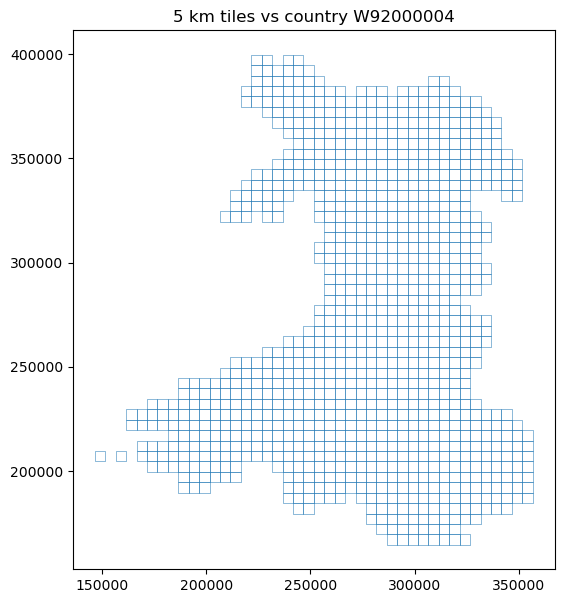

In [3]:
ctry_code = "W92000004"  # England; swap for W92000004 (Wales), S92000003 (Scotland), N92000002 (NI), etc.
country = countries[countries[code_col] == ctry_code]
tiles_ctry = tiles[tiles["ctry"] == ctry_code]

ax = country.boundary.plot(figsize=(7,7), linewidth=2)
tiles_ctry.boundary.plot(ax=ax, linewidth=0.6, alpha=0.6)
ax.set_title(f"5 km tiles vs country {ctry_code}")
ax.set_aspect("equal")
plt.show()
